# 05 — ML Preprocessing

movies_merged.csv is prepared for machine learning.
Categorical columns are encoded, feature matrix (X) and target (y) are separated, and train/test split is applied.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve().parents[1]
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from Source.scripts.helpers import PROCESSED_DATA_DIR

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

df = pd.read_csv(PROCESSED_DATA_DIR / 'movies_merged.csv')
print(f'Loaded {len(df)} rows')

Loaded 5381 rows


## 1. Feature Selection

**Target:** `revenue`

**Features:** `budget`, `runtime`, `release_year`, `primary_genre`, `decade`

**Why these features?**
- `budget` — expected to be the strongest predictor (as seen in EDA)
- `runtime`, `release_year` — general film properties available before release
- `primary_genre`, `decade` — categorical, will be one-hot encoded

In [2]:
FEATURES = ['budget', 'runtime', 'release_year', 'primary_genre', 'decade']
TARGET   = 'revenue'

ml_df = df[FEATURES + [TARGET]].dropna()
print(f'After dropping nulls: {len(ml_df)} rows')
ml_df.head(3)

After dropping nulls: 5368 rows


,budget,runtime,release_year,primary_genre,decade,revenue
0,30000000.0,81.0,1995,Animation,1990s,373554033.0
1,65000000.0,104.0,1995,Adventure,1990s,262797249.0
2,16000000.0,127.0,1995,Comedy,1990s,81452156.0


## 2. Encode Categorical Columns (One-Hot)

In [3]:
ml_encoded = pd.get_dummies(ml_df, columns=['primary_genre', 'decade'], drop_first=True)
print(f'Shape after encoding: {ml_encoded.shape}')
print('Feature columns:', [c for c in ml_encoded.columns if c != TARGET])

Shape after encoding: (5368, 33)
Feature columns: ['budget', 'runtime', 'release_year', 'primary_genre_Adventure', 'primary_genre_Animation', 'primary_genre_Comedy', 'primary_genre_Crime', 'primary_genre_Documentary', 'primary_genre_Drama', 'primary_genre_Family', 'primary_genre_Fantasy', 'primary_genre_Foreign', 'primary_genre_History', 'primary_genre_Horror', 'primary_genre_Music', 'primary_genre_Mystery', 'primary_genre_Romance', 'primary_genre_Science Fiction', 'primary_genre_TV Movie', 'primary_genre_Thriller', 'primary_genre_War', 'primary_genre_Western', 'decade_1920s', 'decade_1930s', 'decade_1940s', 'decade_1950s', 'decade_1960s', 'decade_1970s', 'decade_1980s', 'decade_1990s', 'decade_2000s', 'decade_2010s']


## 3. Train / Test Split

80% train, 20% test — random_state=42 for reproducibility.

In [4]:
X = ml_encoded.drop(columns=[TARGET])
y = ml_encoded[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'X_train: {X_train.shape}  |  X_test: {X_test.shape}')
print(f'y_train: {y_train.shape}  |  y_test: {y_test.shape}')

X_train: (4294, 32)  |  X_test: (1074, 32)
y_train: (4294,)  |  y_test: (1074,)


## 4. Feature Scaling (Linear Regression only)

Random Forest does not require scaling, but StandardScaler is applied for Linear Regression.
Both scaled and unscaled versions of X are kept so each model gets the right input.

In [5]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('Scaling complete')
print(f'Feature mean (train, first 3): {X_train_scaled.mean(axis=0)[:3].round(4)}')

Scaling complete
Feature mean (train, first 3): [ 0.  0. -0.]


## 5. Feature Summary

Distribution of numeric features going into the model — check for outliers.

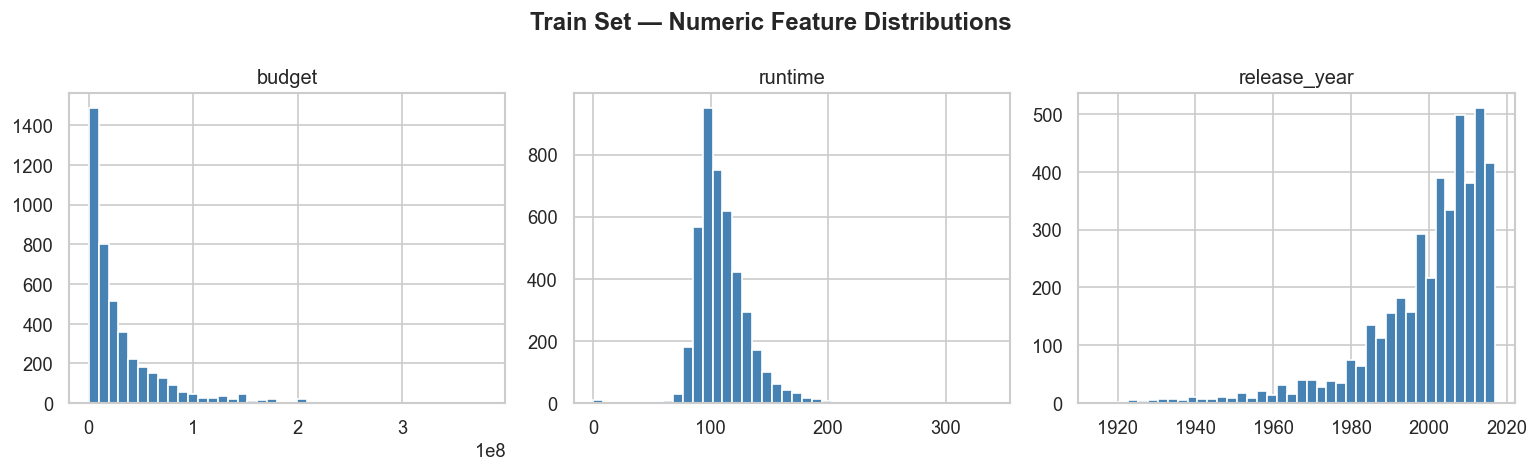

In [6]:
numeric_features = ['budget', 'runtime', 'release_year']
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, col in zip(axes, numeric_features):
    ax.hist(X_train[col].dropna(), bins=40, color='steelblue', edgecolor='white')
    ax.set_title(col)
    ax.set_xlabel('')
plt.suptitle('Train Set — Numeric Feature Distributions', fontweight='bold')
plt.tight_layout()
plt.show()

## Note

The variables `X_train`, `X_test`, `y_train`, `y_test`, `X_train_scaled`, `X_test_scaled`, and `scaler`
are defined in this kernel. Make sure you have run this notebook before opening `06_ml_models.ipynb`.